In [15]:
import os
import pandas as pd
import pingouin as pg
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from pathlib import Path
import glob

In [16]:
FIG_DIR = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)

In [17]:
csvs = Path("../results/hlm_mlm_cv_compare").glob("**/*summary.csv")

summary_csvs =[]
count = 0
for csv in csvs:
  # print(csv)
  df = pd.read_csv(csv)
  summary_csvs.append(df)
  count += 1 

print(count)
# print(summary_csvs)

summary_df = pd.concat(summary_csvs)

# for rmANOVA 
summary_df["sample"] = (
    summary_df["cv_iter"].astype(str) + "_" + summary_df["fold"].astype(str)
)

summary_df

21


,target,n_test,split_method,model_family,cv_iter,fold,rmse,mae,r2,kendall_tau,kendall_tau_pvalue,comparison_label,n_train,n_val,sample
0,HLM,748.0,Scaffold,ChemProp_ST,0,0,0.474765,0.350378,0.439122,0.502313,1.694995e-93,HLM_ChemProp_ST_Scaffold,NaN,NaN,0_0
1,HLM,749.0,Scaffold,ChemProp_ST,0,1,0.464543,0.350983,0.485969,0.528660,1.125686e-103,HLM_ChemProp_ST_Scaffold,NaN,NaN,0_1
2,HLM,747.0,Scaffold,ChemProp_ST,0,2,0.444764,0.334664,0.409390,0.485372,1.770341e-87,HLM_ChemProp_ST_Scaffold,NaN,NaN,0_2
3,HLM,749.0,Scaffold,ChemProp_ST,0,3,0.500732,0.377958,0.386679,0.483947,4.369593e-87,HLM_ChemProp_ST_Scaffold,NaN,NaN,0_3
4,HLM,747.0,Scaffold,ChemProp_ST,0,4,0.505194,0.385718,0.358455,0.451824,5.266624e-76,HLM_ChemProp_ST_Scaffold,NaN,NaN,0_4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45,MLM,NaN,Random,RF_ECFP4,4,2,0.437306,0.307002,0.623152,0.613802,3.125757e-139,MLM_RF_ECFP4_Random,2992.0,748.0,4_2
46,HLM,NaN,Random,RF_ECFP4,4,3,0.440437,0.322401,0.510546,0.542058,1.048607e-108,HLM_RF_ECFP4_Random,2992.0,748.0,4_3
47,MLM,NaN,Random,RF_ECFP4,4,3,0.463114,0.335689,0.587845,0.593114,4.109616e-130,MLM_RF_ECFP4_Random,2992.0,748.0,4_3
48,HLM,NaN,Random,RF_ECFP4,4,4,0.406805,0.302952,0.572972,0.583464,1.182425e-125,HLM_RF_ECFP4_Random,2992.0,748.0,4_4


# Seperating dataframes for rmANOVA

In [18]:
SPLIT_METHODS = ["Random", "Scaffold", "Butina"] 
TARGETS = ["HLM", "MLM"]
METRIC = "mae"

# We needs dataframes with one target at a time, then subdivide for splitting methods

# This seems dumb.
# HLM_df = summary_df[(summary_df["target"]) == "HLM"]
# MLM_df = summary_df[(summary_df["target"]) == "MLM"]

# HLM_Random = HLM_df[(HLM_df["split_method"]) == "Random"]
# HLM_Scaffold = HLM_df[(HLM_df["split_method"]) == "Scaffold"]
# HLM_Split = HLM_df[(HLM_df["split_method"]) == "Butina"]

# MLM_Random = MLM_df[(MLM_df["split_method"]) == "Random"]
# MLM_Scaffold = MLM_df[(MLM_df["split_method"]) == "Scaffold"]
# MLM_Split = MLM_df[(MLM_df["split_method"]) == "Butina"]

# This is better
rmANOVAs = []

for target in TARGETS:
    for split_method in SPLIT_METHODS:
        print(f"rmANOVA for: {target}, {split_method}")
        df = pg.rm_anova(
            data=summary_df[
                (summary_df["target"] == target)
                & (summary_df["split_method"] == split_method)
            ],
            dv=METRIC,
            within="model_family",
            subject="sample",
        )
        df["target_split"] = target + "_" + split_method
        display(df)
        rmANOVAs.append(df)
        if "sphericity" in df.columns and (df["p_spher"].iloc[0] < 0.05):
            if df["p_GG_corr"].iloc[0] < 0.05:
                print(
                    f"Sphericity was violated for {target} using {split_method}, so the Greenhouse-Geisser corrected p-value was used. "
                    f"The rmANOVA was significant, so we reject the null hypothesis that mean {METRIC} is equal across model families."
                )
            else:
                print(
                    f"Sphericity was violated for {target} using {split_method}, so the Greenhouse-Geisser corrected p-value was used. "
                    f"The rmANOVA was not significant, so we fail to reject the null hypothesis that mean {METRIC} is equal across model families."
                )

        elif "p_unc" in df.columns and (df["p_unc"].iloc[0] < 0.05):
            print(
                f"The rmANOVA was significant for {target} using {split_method}, so we reject the null hypothesis that mean {METRIC} is equal across model families."
            )

        elif "p_unc" in df.columns and (df["p_unc"].iloc[0] >= 0.05):
            print(
                f"The rmANOVA was not significant for {target} using {split_method}, so we fail to reject the null hypothesis that mean {METRIC} is equal across model families."
            )

len(rmANOVAs)

rmANOVA for: HLM, Random


,Source,ddof1,ddof2,F,p_unc,p_GG_corr,ng2,eps,sphericity,W_spher,p_spher,target_split
0,model_family,4,96,420.510007,6.582972e-60,7.221667e-32,0.855482,0.51245,False,0.134141,9.841804e-07,HLM_Random


Sphericity was violated for HLM using Random, so the Greenhouse-Geisser corrected p-value was used. The rmANOVA was significant, so we reject the null hypothesis that mean mae is equal across model families.
rmANOVA for: HLM, Scaffold


,Source,ddof1,ddof2,F,p_unc,p_GG_corr,ng2,eps,sphericity,W_spher,p_spher,target_split
0,model_family,4,96,134.885863,1.654622e-38,2.623034e-26,0.575547,0.66236,False,0.246265,0.000261,HLM_Scaffold


Sphericity was violated for HLM using Scaffold, so the Greenhouse-Geisser corrected p-value was used. The rmANOVA was significant, so we reject the null hypothesis that mean mae is equal across model families.
rmANOVA for: HLM, Butina


...

,Source,ddof1,ddof2,F,p_unc,ng2,eps,target_split
0,model_family,4,96,109.185725,7.621125e-35,0.448685,0.77694,MLM_Scaffold


The rmANOVA was significant for MLM using Scaffold, so we reject the null hypothesis that mean mae is equal across model families.
rmANOVA for: MLM, Butina


,Source,ddof1,ddof2,F,p_unc,p_GG_corr,ng2,eps,sphericity,W_spher,p_spher,target_split
0,model_family,4,96,155.237313,5.184502e-41,2.074888e-22,0.482188,0.518731,False,0.210839,0.000065,MLM_Butina


Sphericity was violated for MLM using Butina, so the Greenhouse-Geisser corrected p-value was used. The rmANOVA was significant, so we reject the null hypothesis that mean mae is equal across model families.


6

Tukey HSD for: HLM, Random
Lowest avg. MAE model family: ChemProp_ST_FM (0.297506)
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------
   ChemProp_MT ChemProp_MT_FM  -0.0476    0.0 -0.0545 -0.0407   True
   ChemProp_MT    ChemProp_ST  -0.0098 0.0013 -0.0167 -0.0029   True
   ChemProp_MT ChemProp_ST_FM  -0.0508    0.0 -0.0577 -0.0439   True
   ChemProp_MT       RF_ECFP4  -0.0428    0.0 -0.0497 -0.0359   True
ChemProp_MT_FM    ChemProp_ST   0.0378    0.0  0.0309  0.0447   True
ChemProp_MT_FM ChemProp_ST_FM  -0.0032 0.7035 -0.0101  0.0037  False
ChemProp_MT_FM       RF_ECFP4   0.0048 0.3078 -0.0021  0.0117  False
   ChemProp_ST ChemProp_ST_FM   -0.041    0.0 -0.0479 -0.0341   True
   ChemProp_ST       RF_ECFP4   -0.033    0.0 -0.0399 -0.0261   True
ChemProp_ST_FM       RF_ECFP4    0.008 0.0145  0.0011  0.0149   True
--------------------

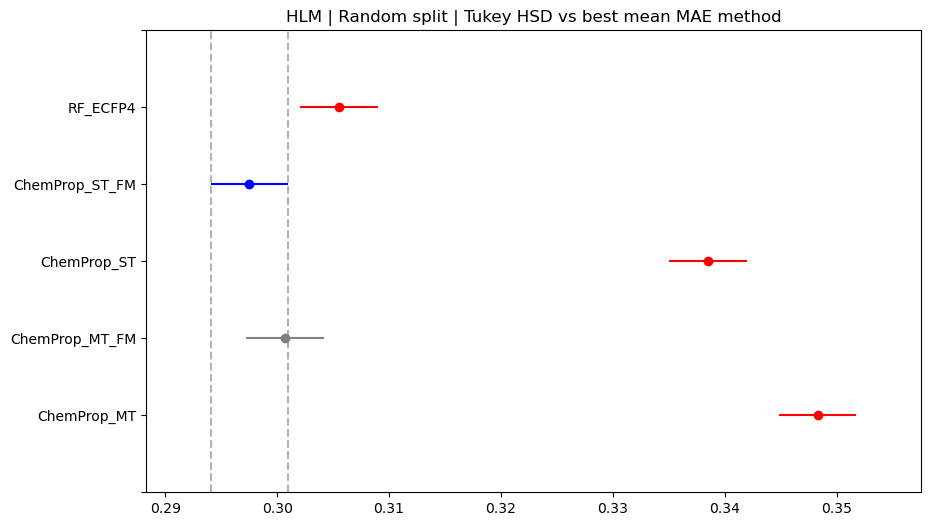

Tukey HSD for: HLM, Scaffold
Lowest avg. MAE model family: ChemProp_ST_FM (0.326112)
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------
   ChemProp_MT ChemProp_MT_FM  -0.0403    0.0 -0.0517 -0.0288   True
   ChemProp_MT    ChemProp_ST  -0.0078   0.33 -0.0192  0.0036  False
   ChemProp_MT ChemProp_ST_FM  -0.0404    0.0 -0.0518  -0.029   True
   ChemProp_MT       RF_ECFP4  -0.0279    0.0 -0.0393 -0.0165   True
ChemProp_MT_FM    ChemProp_ST   0.0325    0.0  0.0211  0.0439   True
ChemProp_MT_FM ChemProp_ST_FM  -0.0001    1.0 -0.0116  0.0113  False
ChemProp_MT_FM       RF_ECFP4   0.0124 0.0271  0.0009  0.0238   True
   ChemProp_ST ChemProp_ST_FM  -0.0326    0.0  -0.044 -0.0212   True
   ChemProp_ST       RF_ECFP4  -0.0201    0.0 -0.0316 -0.0087   True
ChemProp_ST_FM       RF_ECFP4   0.0125 0.0248  0.0011  0.0239   True
------------------

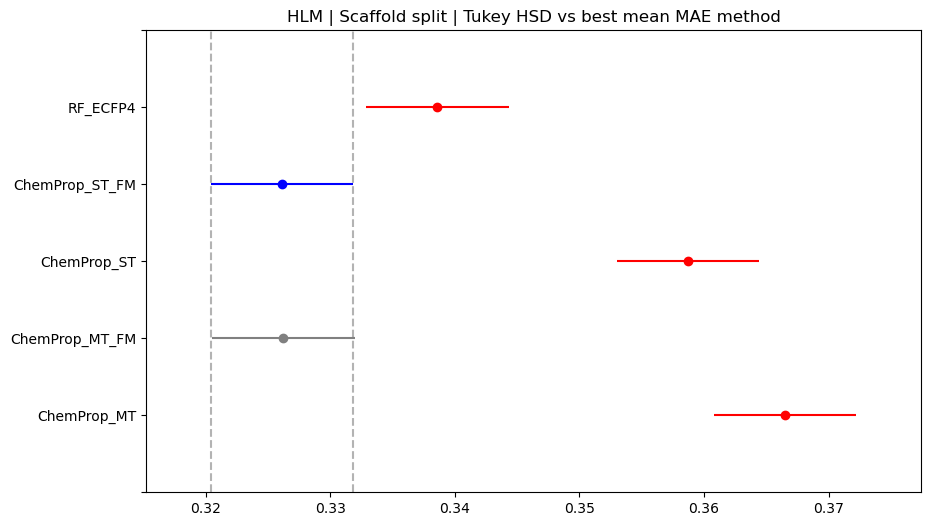

Tukey HSD for: HLM, Butina
Lowest avg. MAE model family: ChemProp_ST_FM (0.324987)
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------
   ChemProp_MT ChemProp_MT_FM  -0.0352    0.0 -0.0434 -0.0269   True
   ChemProp_MT    ChemProp_ST  -0.0065 0.1906 -0.0148  0.0017  False
   ChemProp_MT ChemProp_ST_FM  -0.0381    0.0 -0.0464 -0.0298   True
   ChemProp_MT       RF_ECFP4  -0.0233    0.0 -0.0316 -0.0151   True
ChemProp_MT_FM    ChemProp_ST   0.0286    0.0  0.0204  0.0369   True
ChemProp_MT_FM ChemProp_ST_FM   -0.003 0.8596 -0.0112  0.0053  False
ChemProp_MT_FM       RF_ECFP4   0.0118 0.0011  0.0036  0.0201   True
   ChemProp_ST ChemProp_ST_FM  -0.0316    0.0 -0.0398 -0.0233   True
   ChemProp_ST       RF_ECFP4  -0.0168    0.0  -0.025 -0.0085   True
ChemProp_ST_FM       RF_ECFP4   0.0148    0.0  0.0065   0.023   True
--------------------

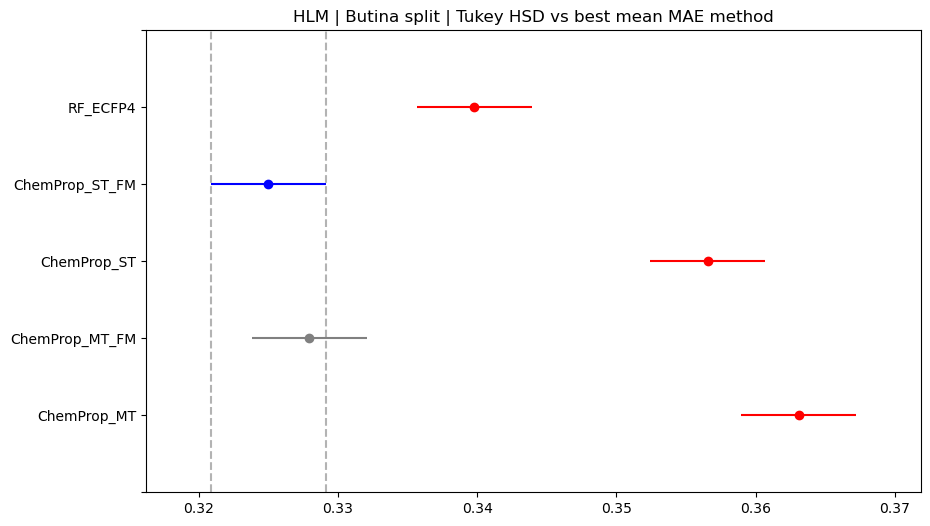

Tukey HSD for: MLM, Random
Lowest avg. MAE model family: ChemProp_ST_FM (0.320428)
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------
   ChemProp_MT ChemProp_MT_FM  -0.0486    0.0  -0.056 -0.0413   True
   ChemProp_MT    ChemProp_ST  -0.0079 0.0303 -0.0152 -0.0005   True
   ChemProp_MT ChemProp_ST_FM  -0.0488    0.0 -0.0561 -0.0414   True
   ChemProp_MT       RF_ECFP4  -0.0466    0.0 -0.0539 -0.0392   True
ChemProp_MT_FM    ChemProp_ST   0.0408    0.0  0.0334  0.0481   True
ChemProp_MT_FM ChemProp_ST_FM  -0.0001    1.0 -0.0075  0.0072  False
ChemProp_MT_FM       RF_ECFP4   0.0021 0.9345 -0.0053  0.0094  False
   ChemProp_ST ChemProp_ST_FM  -0.0409    0.0 -0.0483 -0.0336   True
   ChemProp_ST       RF_ECFP4  -0.0387    0.0 -0.0461 -0.0313   True
ChemProp_ST_FM       RF_ECFP4   0.0022 0.9189 -0.0051  0.0096  False
--------------------

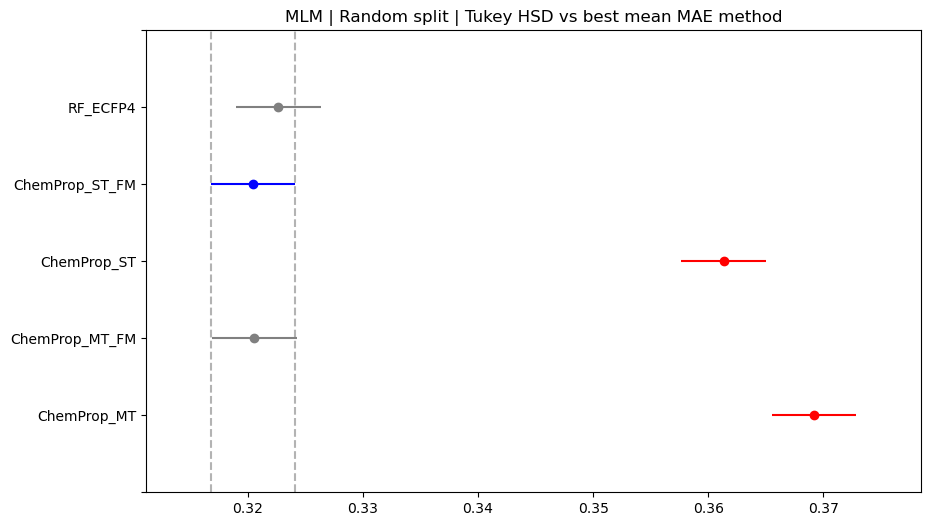

Tukey HSD for: MLM, Scaffold
Lowest avg. MAE model family: ChemProp_MT_FM (0.347204)
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------
   ChemProp_MT ChemProp_MT_FM  -0.0366    0.0 -0.0499 -0.0233   True
   ChemProp_MT    ChemProp_ST  -0.0062 0.6946 -0.0195  0.0071  False
   ChemProp_MT ChemProp_ST_FM   -0.034    0.0 -0.0473 -0.0208   True
   ChemProp_MT       RF_ECFP4   -0.028    0.0 -0.0412 -0.0147   True
ChemProp_MT_FM    ChemProp_ST   0.0304    0.0  0.0171  0.0436   True
ChemProp_MT_FM ChemProp_ST_FM   0.0026 0.9837 -0.0107  0.0158  False
ChemProp_MT_FM       RF_ECFP4   0.0086 0.3804 -0.0047  0.0219  False
   ChemProp_ST ChemProp_ST_FM  -0.0278    0.0 -0.0411 -0.0145   True
   ChemProp_ST       RF_ECFP4  -0.0218 0.0001  -0.035 -0.0085   True
ChemProp_ST_FM       RF_ECFP4    0.006 0.7145 -0.0072  0.0193  False
------------------

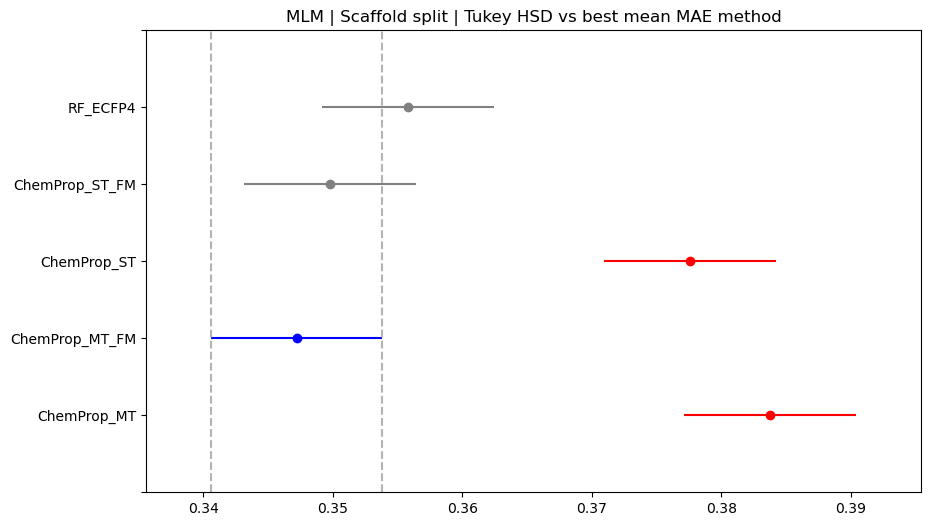

Tukey HSD for: MLM, Butina
Lowest avg. MAE model family: ChemProp_MT_FM (0.345424)
        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------
   ChemProp_MT ChemProp_MT_FM  -0.0393    0.0 -0.0527 -0.0258   True
   ChemProp_MT    ChemProp_ST  -0.0062 0.7119 -0.0197  0.0073  False
   ChemProp_MT ChemProp_ST_FM  -0.0379    0.0 -0.0514 -0.0244   True
   ChemProp_MT       RF_ECFP4  -0.0283    0.0 -0.0418 -0.0149   True
ChemProp_MT_FM    ChemProp_ST   0.0331    0.0  0.0196  0.0466   True
ChemProp_MT_FM ChemProp_ST_FM   0.0014 0.9987 -0.0121  0.0148  False
ChemProp_MT_FM       RF_ECFP4   0.0109 0.1725 -0.0026  0.0244  False
   ChemProp_ST ChemProp_ST_FM  -0.0317    0.0 -0.0452 -0.0182   True
   ChemProp_ST       RF_ECFP4  -0.0222 0.0001 -0.0357 -0.0087   True
ChemProp_ST_FM       RF_ECFP4   0.0095 0.2913 -0.0039   0.023  False
--------------------

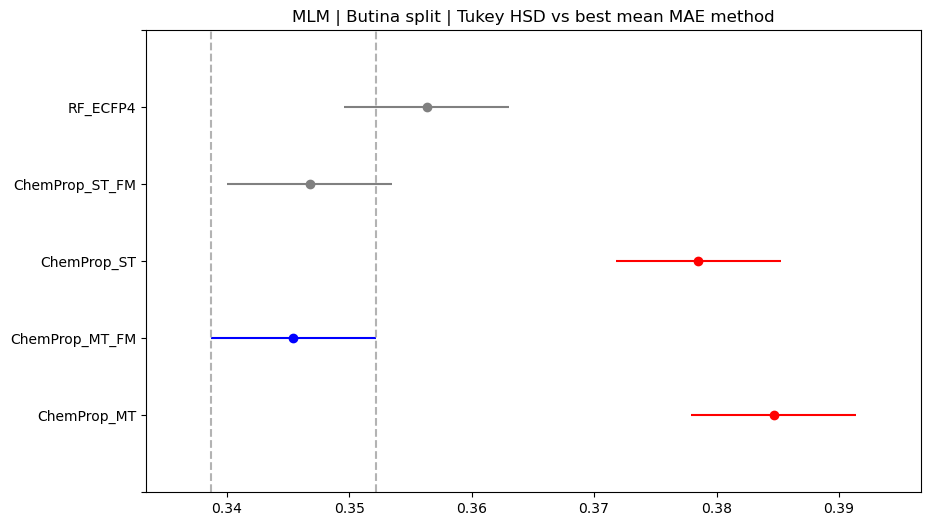

In [67]:
for target in TARGETS:
    for split_method in SPLIT_METHODS:
        print(f"Tukey HSD for: {target}, {split_method}")
        df = summary_df[
                (summary_df["target"] == target)
                & (summary_df["split_method"] == split_method)
            ]
        avg_mae_min = df.groupby("model_family")["mae"].mean().min()
        avg_mae_idx = df.groupby("model_family")["mae"].mean().idxmin()
        print(f"Lowest avg. MAE model family: {avg_mae_idx} ({avg_mae_min:4f})")
        tukey = pairwise_tukeyhsd(
            endog=df["mae"], groups=df["model_family"], alpha=0.05
        )
        print(tukey)
        tukey_plot = tukey.plot_simultaneous(comparison_name=avg_mae_idx)
        plt.title(
            f"{target} | {split_method} split | Tukey HSD vs best mean MAE method"
        )
        tukey_path = os.path.join(
            FIG_DIR,
            f"{split_method.lower()}_{target.lower()}_tukey_vs_best_mae.png",
        )
        plt.savefig(tukey_path, dpi=300, bbox_inches="tight")
        plt.show()

In [65]:
for target in TARGETS:
    for split_method in SPLIT_METHODS:
        print(f"Tukey HSD for: {target}, {split_method}")
        df = summary_df[
            (summary_df["target"] == target)
            & (summary_df["split_method"] == split_method)
        ]
        avg_mae = df.groupby("model_family")["mae"].mean().min()
        print(f"{avg_mae:4f}")

Tukey HSD for: HLM, Random
0.297506
Tukey HSD for: HLM, Scaffold
0.326112
Tukey HSD for: HLM, Butina
0.324987
Tukey HSD for: MLM, Random
0.320428
Tukey HSD for: MLM, Scaffold
0.347204
Tukey HSD for: MLM, Butina
0.345424


In [ ]:
# Summary table for MAE
summary = (
    df.groupby("method", as_index=False)[METRIC]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .reset_index()
    .sort_values("mean", ascending=True)
)

summary




In [ ]:
# The method with the lowest mean MAE is the one we treat as appearing best
best_method = summary.iloc[0]["method"]
best_mae = summary.iloc[0]["mean"]

print(f"Best method by mean {METRIC.upper()} for {TARGET} on {SPLIT_METHOD}:")
print(f"{best_method} (mean {METRIC} = {best_mae:.4f})")




In [ ]:
# Boxplot of fold-level MAE values
plot_order = summary["method"].tolist()

plot_data = [df.loc[df["method"] == method, METRIC].tolist() for method in plot_order]

plt.figure(figsize=(8, 5))
plt.boxplot(plot_data, tick_labels=plot_order)
plt.ylabel("MAE")
plt.title(f"{TARGET} | {SPLIT_METHOD} split | method comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()




In [ ]:
# Tukey HSD on fold-level MAE values
# This is a simple first pass using the 25 fold-level values per method.
mc = MultiComparison(df[METRIC], df["method"])
tukey = mc.tukeyhsd()

print(tukey)




In [ ]:
# Turn Tukey results into a dataframe for easier viewing later
tukey_df = pd.DataFrame(
    tukey._results_table.data[1:],
    columns=tukey._results_table.data[0],
)

tukey_df = tukey_df.sort_values(
    ["reject", "p-adj"],
    ascending=[False, True],
).reset_index(drop=True)

tukey_df




In [ ]:
# Pull out the MAE means again in a compact table for interpretation
mean_table = (
    df.groupby("method", as_index=False)[METRIC]
    .mean()
    .rename(columns={METRIC: "mean_mae"})
    .sort_values("mean_mae", ascending=True)
    .reset_index(drop=True)
)

mean_table




In [ ]:
# We use the method with the lowest mean MAE as the reference method
best_method = mean_table.iloc[0]["method"]
best_mae = mean_table.iloc[0]["mean_mae"]

print("Reference method for Tukey comparison:")
print(f"{best_method} (mean MAE = {best_mae:.4f})")

# We follow the convention of Ash et al:
tukey.plot_simultaneous(comparison_name=best_method)
plt.title(f"{TARGET} | {SPLIT_METHOD} split | Tukey HSD vs best mean MAE method")
plt.tight_layout()

tukey_path = os.path.join(
    FIG_DIR,
    f"{SPLIT_METHOD.lower()}_{TARGET.lower()}_tukey_vs_best_{METRIC.lower()}.png",
)
plt.savefig(tukey_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {tukey_path}")


